You need
LANGSMITH_API_KEY (and your LangSmith project name).

*   [OPENAI_API_KEY](https://platform.openai.com/api-keys)
*   [LANGSMITH_API_KEY](https://smith.langchain.com/o/dfb4c27f-730c-5be2-a2a4-34df91381a75/settings/apikeys)
*   [LangSmith project name](https://smith.langchain.com/o/dfb4c27f-730c-5be2-a2a4-34df91381a75/projects)



In [2]:
!pip -q install -U langchain langchain-openai langgraph langsmith python-dotenv pydantic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.3/114.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.3/234.3 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.6/399.6 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pydant

In [3]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# LangSmith
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGCHAIN_PROJECT", "AIAgents")
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

print("Tracing:", os.environ["LANGCHAIN_TRACING_V2"])
print("Project:", os.environ["LANGCHAIN_PROJECT"])


Tracing: true
Project: AIAgents


In [4]:
from typing import List, Dict, Any, Optional, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)


# Single Agent

In [5]:
SINGLE_AGENT_SYSTEM = """You are a helpful AI.
Task: Provide a well-reasoned recommendation to the user question.
Rules:
- Make your best effort without browsing the web.
- Be structured: Summary, Pros, Cons, Recommendation, Risks, Confidence (0-100).
"""

def single_agent_answer(question: str) -> str:
    msgs = [
        SystemMessage(content=SINGLE_AGENT_SYSTEM),
        HumanMessage(content=question),
    ]
    return llm.invoke(msgs).content

question = "Should a startup use open-source LLMs or closed models in 2026? Consider cost, speed, privacy, and reliability."
print(single_agent_answer(question))


### Summary
In 2026, the decision for a startup to use open-source large language models (LLMs) versus closed models will depend on several factors including cost, speed, privacy, and reliability. Each option has its own set of advantages and disadvantages that can significantly impact the startup's operations and strategic goals.

### Pros and Cons

#### Open-Source LLMs

**Pros:**
- **Cost-Effective:** Generally, open-source models can be used without licensing fees, which can significantly reduce operational costs.
- **Customization:** Startups can modify and fine-tune the models to better suit their specific needs and applications.
- **Transparency:** Open-source models allow for greater scrutiny and understanding of the underlying algorithms, which can enhance trust and security.
- **Community Support:** A large community often contributes to improvements, bug fixes, and shared knowledge.

**Cons:**
- **Resource Intensive:** Running and maintaining open-source models may require s

# Multi-Agent System with LangGraph + LangSmith

[Main idea](https://drive.google.com/file/d/1jWx_XLA-Iva_lQ0uIPtua9iWq06Ap929/view?usp=sharing)



*   Planner: Breaks the user’s question into a clear plan, key risks, and the structure of the final answer.
*   Researcher: Gathers and organizes relevant information needed to execute the plan.
*   Writer: Produces or revises the draft answer based on the plan, research, and feedback.
*   Critic: Evaluates the draft for quality, gaps, and risks, and assigns a score with concrete improvement suggestions.
*   finalizer: Produces the final, polished answer once the quality threshold is met.


In [6]:
#Define structured outputs
class Plan(BaseModel):
    steps: List[str] = Field(..., description="Short ordered steps for solving the task.")
    key_risks: List[str] = Field(..., description="Major risks/unknowns that should be addressed.")
    desired_output_structure: List[str] = Field(..., description="Headings to include in final answer.")

class Critique(BaseModel):
    issues: List[str] = Field(..., description="Concrete problems with the current draft.")
    missing_points: List[str] = Field(..., description="Important missing considerations.")
    hallucination_risk: List[str] = Field(..., description="Claims that might be risky without sources.")
    score: int = Field(..., ge=0, le=100, description="Overall quality score of the draft.")
    fix_instructions: List[str] = Field(..., description="Actionable steps to improve the draft.")
#Define LangGraph state

class GraphState(TypedDict):
    question: str
    plan: Optional[Dict[str, Any]]
    research_notes: List[str]
    draft: Optional[str]
    critique: Optional[Dict[str, Any]]
    iteration: int
    max_iterations: int


In [7]:
# Agent nodes (Planner, Researcher, Writer, Critic, finalizer)

PLANNER_SYSTEM = """You are the Planner agent.
Create a concise plan with steps, key risks, and final output headings.
Return valid JSON matching the schema.
"""

RESEARCHER_SYSTEM = """You are the Researcher agent.
You do NOT browse the web. You reason from general knowledge.
Produce bullet research notes covering: cost, speed, privacy, reliability, compliance, vendor lock-in, iteration speed, support.
Keep it practical for startups.
"""

WRITER_SYSTEM = """You are the Writer agent.
Write a structured answer using the plan headings.
Use the research notes.
Be specific, actionable, and include a clear recommendation plus risks.
"""

CRITIC_SYSTEM = """You are the Critic agent.
Review the draft for:
- missing points
- weak reasoning
- overconfidence
- risky claims
Return JSON matching the schema.
"""

FUNALIZER_SYSTEM = """You are the finalizer agent.
Given the plan + research notes + (optional) critique, produce the FINAL answer.
If critique exists, incorporate fixes.
Output must be polished and concise with headings and a confidence score.
"""

def planner_node(state: GraphState) -> GraphState:
    structured_planner = llm.with_structured_output(Plan)
    plan_obj = structured_planner.invoke([
        SystemMessage(content=PLANNER_SYSTEM),
        HumanMessage(content=state["question"])
    ])
    state["plan"] = plan_obj.model_dump()
    return state

def researcher_node(state: GraphState) -> GraphState:
    resp = llm.invoke([
        SystemMessage(content=RESEARCHER_SYSTEM),
        HumanMessage(content=f"Question:\n{state['question']}\n\nPlan:\n{state['plan']}")
    ]).content

    # store as notes (simple split)
    notes = [line.strip("- ").strip() for line in resp.split("\n") if line.strip()]
    state["research_notes"] = notes
    return state

def writer_node(state: GraphState) -> GraphState:
    resp = llm.invoke([
        SystemMessage(content=WRITER_SYSTEM),
        HumanMessage(content=f"""
        Question:
        {state['question']}

        Plan:
        {state['plan']}

        Research notes:
        {state['research_notes']}

        If critique exists, you may improve the draft accordingly.
        Critique:
        {state.get('critique')}
        """)
            ]).content

    state["draft"] = resp
    return state



def critic_node(state: GraphState) -> GraphState:
    structured_critic = llm.with_structured_output(Critique)
    critique_obj = structured_critic.invoke([
        SystemMessage(content=CRITIC_SYSTEM),
        HumanMessage(content=f"""
    Question:
    {state['question']}

    Draft:
    {state['draft']}
    """)
        ])

    state["critique"] = critique_obj.model_dump()
    state["iteration"] += 1

    return state




def finalizer_node(state: GraphState) -> GraphState:
    resp = llm.invoke([
        SystemMessage(content=FUNALIZER_SYSTEM),
        HumanMessage(content=f"""
Question:
{state['question']}

Plan:
{state['plan']}

Research notes:
{state['research_notes']}

Critique (if any):
{state.get('critique')}

Current draft (if any):
{state.get('draft')}
""")
    ]).content

    state["draft"] = resp
    return state


## Build LangGraph (conditional loop + stop condition)

In [8]:
from langgraph.graph import StateGraph, END


def should_revise(state: GraphState) -> Literal["revise", "finalize"]:
    score = state["critique"]["score"]

    if state["iteration"] >= state["max_iterations"]:
        return "finalize"

    if score < 80:
        return "revise"

    return "finalize"


workflow = StateGraph(GraphState)

workflow.add_node("planner", planner_node)
workflow.add_node("researcher", researcher_node)
workflow.add_node("writer", writer_node)
workflow.add_node("critic", critic_node)
workflow.add_node("finalizer", finalizer_node)

workflow.set_entry_point("planner")

workflow.add_edge("planner", "researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", "critic")

# conditional edge to loop or finalize
workflow.add_conditional_edges(
    "critic",
    should_revise,
    {
        "revise": "writer",
        "finalize": "finalizer",
    }
)

workflow.add_edge("finalizer", END)

app = workflow.compile()


**Graph visualization**

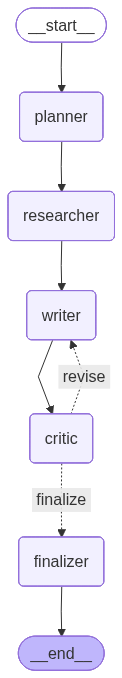

In [9]:
#visualize graph


try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization skipped:", e)


## Run the Multi-Agent Graph

In [10]:
question

'Should a startup use open-source LLMs or closed models in 2026? Consider cost, speed, privacy, and reliability.'

In [11]:
initial_state: GraphState = {
    "question": question,
    "plan": None,
    "research_notes": [],
    "draft": None,
    "critique": None,
    "iteration": 0,
    "max_iterations": 2,
}



result = app.invoke(initial_state)
print(result["draft"])


# Should a Startup Use Open-Source LLMs or Closed Models in 2026?

## Introduction
In 2026, startups face a pivotal decision between utilizing open-source large language models (LLMs) and closed models. This choice is influenced by several factors, including cost, speed, privacy, and reliability. Each option presents distinct advantages and challenges that must be thoroughly evaluated. This analysis aims to provide actionable insights to guide startups in making an informed decision.

## Cost Analysis
### Open-Source LLMs
- **Cost Structure**: Generally free to use, but startups may incur costs related to infrastructure, maintenance, and hiring specialized talent. For instance, cloud services or on-premise hardware can lead to significant expenses.
- **Community Support**: While community-driven support can reduce costs, it may lack consistency and reliability. Startups should budget for potential hiring of experts to manage and optimize these models.

### Closed Models
- **Cost Struct

# compare single vs multi agents

In [12]:
def run_comparison(question: str):
    print("====== Single Agent ======")
    print(single_agent_answer(question))
    print("\n\n====== Multi-Agent (LangGraph) ======")
    initial_state: GraphState = {
        "question": question,
        "plan": None,
        "research_notes": [],
        "draft": None,
        "critique": None,
        "iteration": 0,
        "max_iterations": 2,
    }
    result = app.invoke(initial_state)
    print(result["draft"])

run_comparison("Should I build my AI product on open-source LLMs (self-hosted) or closed APIs in 2026 if I handle sensitive customer data?")


====== Single Agent ======
### Summary
When deciding whether to build your AI product on open-source LLMs (self-hosted) or closed APIs in 2026, especially when handling sensitive customer data, several factors should be considered, including data privacy, control, cost, and scalability. 

### Pros and Cons

#### Open-source LLMs (Self-hosted)
**Pros:**
- **Data Privacy:** You have full control over your data, which is crucial when handling sensitive information. No data is sent to third-party servers.
- **Customization:** You can modify the model to suit your specific needs and requirements.
- **Cost-Effective:** Once set up, self-hosted solutions can be more cost-effective in the long run, especially if you have a large volume of data.
- **Transparency:** Open-source models allow you to inspect the code and understand how the model works.

**Cons:**
- **Maintenance:** You are responsible for maintaining the infrastructure, including updates, security patches, and scaling.
- **Technica